In [ ]:
!rm -rf ~/.kaggle


In [ ]:
from google.colab import files
files.upload()


In [ ]:
!mkdir -p ~/.kaggle
!cp 'kaggle (8).json' ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!pip install kaggle


In [ ]:
!kaggle datasets download -d ashishjstar/lettuce-diseases

Dataset URL: https://www.kaggle.com/datasets/ashishjstar/lettuce-diseases
License(s): apache-2.0
100% 1.25G/1.25G [00:13<00:00, 99.4MB/s]



In [ ]:
import zipfile

zip_ref = zipfile.ZipFile('lettuce-diseases.zip', 'r')
zip_ref.extractall('/content/dataset')
zip_ref.close()

In [ ]:
import shutil
import os

source = "/content/dataset"

print(f"Contents of {source}: {os.listdir(source)}")

source = os.path.join(source, 'Lettuce_disease_datasets')
target = "/content/selected_dataset"

classes = [
    "Healthy",
    "Bacterial",
    "Septoria_blight_on_lettuce"
]

os.makedirs(target, exist_ok=True)

for cls in classes:
    class_source_path = os.path.join(source, cls)
    if not os.path.exists(class_source_path):
        print(f"Warning: Source directory not found for class '{cls}': {class_source_path}. Skipping.")
        continue
    shutil.copytree(class_source_path, os.path.join(target, cls))

print(f"Selected dataset created at: {target}")

Contents of /content/dataset: ['Lettuce_disease_datasets']
Selected dataset created at: /content/selected_dataset


In [ ]:
import os

dataset_path = "/content/selected_dataset"

print("📊 Current Dataset Counts:")
for cls in os.listdir(dataset_path):
    path = os.path.join(dataset_path, cls)
    count = len(os.listdir(path))
    print(f"  {cls:<30} {count} images")

📊 Current Dataset Counts:
  Bacterial                      20 images
  Healthy                        1123 images
  Septoria_blight_on_lettuce     19 images


In [ ]:
# ===============================
# IMPORTS
# ===============================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator, img_to_array, load_img
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.metrics import Precision, Recall


# ===============================
# ✅ STEP 1 — AUGMENT MINORITY CLASSES
# Bacterial: 20 → 900 images
# Septoria:  19 → 900 images
# ===============================

augmentor = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.6, 1.4],
    fill_mode="nearest"
)

def augment_class(class_path, target_count=900):
    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    current = len(images)
    needed  = target_count - current

    if needed <= 0:
        print(f"  ✅ {os.path.basename(class_path)}: already has {current} images — skipping")
        return

    print(f"  Augmenting {os.path.basename(class_path)}: {current} → {target_count} (+{needed} images)...")
    saved = 0

    while saved < needed:
        for img_name in images:
            if saved >= needed:
                break
            img = load_img(os.path.join(class_path, img_name),
                           target_size=(224, 224))
            x = img_to_array(img).reshape((1, 224, 224, 3))
            for batch in augmentor.flow(
                x, batch_size=1,
                save_to_dir=class_path,
                save_prefix='aug',
                save_format='jpg'
            ):
                saved += 1
                break

    print(f"  ✅ Done — {len(os.listdir(class_path))} total images")

# Run augmentation on minority classes ONLY
print("🔄 Starting augmentation...\n")
augment_class("/content/selected_dataset/Bacterial",                  target_count=900)
augment_class("/content/selected_dataset/Septoria_blight_on_lettuce", target_count=900)

# Verify counts
print("\n📊 Dataset Counts After Augmentation:")
for cls in sorted(os.listdir("/content/selected_dataset")):
    count  = len(os.listdir(f"/content/selected_dataset/{cls}"))
    status = "✅" if count >= 800 else "⚠️  still low"
    print(f"  {status}  {cls:<30} {count} images")


# ===============================
# DATA GENERATORS
# ===============================

IMG_SIZE   = 224
BATCH_SIZE = 16
target     = "/content/selected_dataset"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

# ✅ No augmentation on validation
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    target,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    target,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False  # ✅ Keep False for correct evaluation
)


# ===============================
# ✅ Compute Class Weights
# ===============================

train_labels         = train_generator.classes
class_weights_array  = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights_array))

print("\n✅ Class Weights:")
label_names = list(train_generator.class_indices.keys())
for idx, weight in class_weight_dict.items():
    print(f"  Class {idx} ({label_names[idx]}): {weight:.4f}")



🔄 Starting augmentation...

  Augmenting Bacterial: 20 → 900 (+880 images)...
  ✅ Done — 862 total images
  Augmenting Septoria_blight_on_lettuce: 19 → 900 (+881 images)...
  ✅ Done — 868 total images

📊 Dataset Counts After Augmentation:
  ✅  Bacterial                      862 images
  ✅  Healthy                        1123 images
  ✅  Septoria_blight_on_lettuce     868 images
Found 2284 images belonging to 3 classes.
Found 569 images belonging to 3 classes.

✅ Class Weights:
  Class 0 (Bacterial): 1.1034
  Class 1 (Healthy): 0.8469
  Class 2 (Septoria_blight_on_lettuce): 1.0954


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - accuracy: 0.8082 - loss: 0.4733 - precision: 0.8184 - recall: 0.7951 - val_accuracy: 0.9016 - val_loss: 0.2368 - val_precision: 0.9048 - val_recall: 0.9016
Epoch 2/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.8897 - loss: 0.2658 - precision: 0.8917 - recall: 0.8866 - val_accuracy: 0.9420 - val_loss: 0.1828 - val_precision: 0.9437 - val_recall: 0.9420
Epoch 3/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.9181 - loss: 0.2174 - precision: 0.9193 - recall: 0.9181 - val_accuracy: 0.9420 - val_loss: 0.1668 - val_precision: 0.9435 - val_recall: 0.9385
Epoch 4/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.9137 - loss: 0.2015 - precision: 0.9144 - recall: 0.9116 - val_accuracy: 0.9473 - val_loss: 0.1379 - val_precision: 0.9473 - val_recall: 0.9473
Epoch 5/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.9304 - loss: 0.1674 - precision: 0.9307 

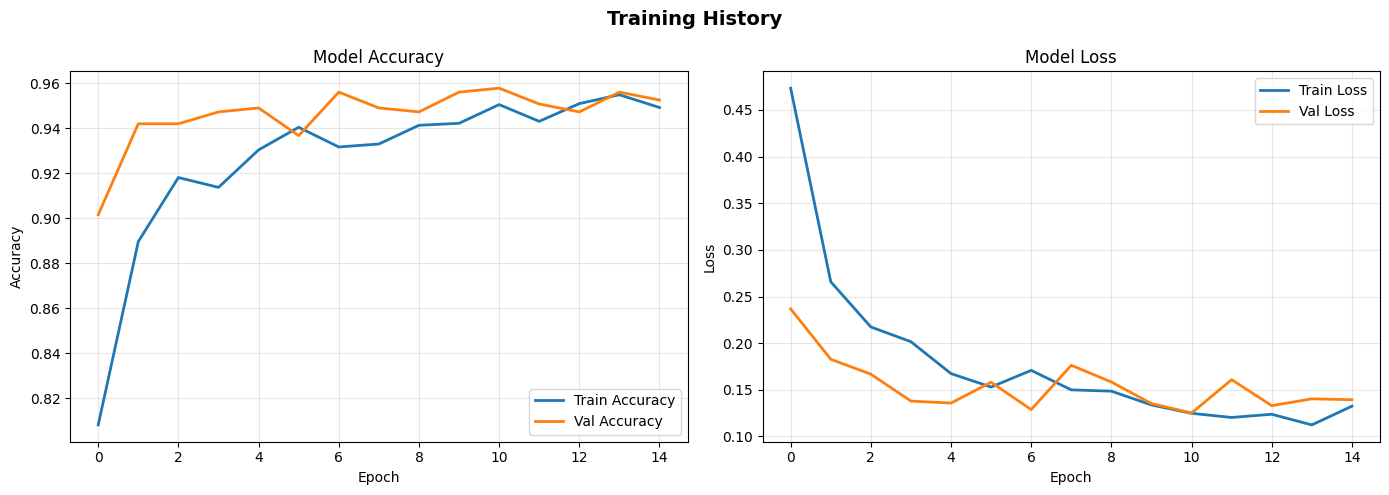

✅ Training curves saved as training_curves.png
✅ Model saved as lettuce_mobilenetv2.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 30s 800ms/step

📊 Classification Report:
                            precision    recall  f1-score   support

                 Bacterial       0.93      0.92      0.92       172
                   Healthy       1.00      0.96      0.98       224
Septoria_blight_on_lettuce       0.92      0.98      0.95       173

                  accuracy                           0.95       569
                 macro avg       0.95      0.95      0.95       569
              weighted avg       0.95      0.95      0.95       569



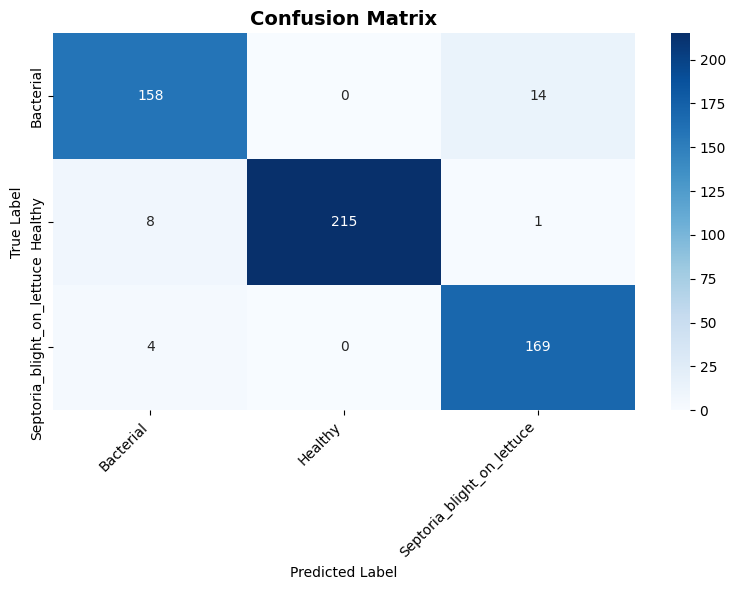

✅ Confusion matrix saved as confusion_matrix.png

📈 Per-Class Accuracy Summary:
  Bacterial                      91.9%  (172 samples)
  Healthy                        96.0%  (224 samples)
  Septoria_blight_on_lettuce     97.7%  (173 samples)

         FINAL ACCURACY — THESIS REPORT
  Overall Accuracy  : 95.25%
  Macro F1-Score    : 0.9501
  Weighted F1-Score : 0.9528


In [ ]:

# ===============================
# STEP 12 — Load MobileNetV2
# ===============================

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

for layer in base_model.layers:
    layer.trainable = False


# ===============================
# STEP 13 — Add Custom Layers
# ===============================

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(3, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)


# ===============================
# STEP 14 — Compile Model
# ===============================

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        Precision(name="precision"),
        Recall(name="recall")
    ]
)


# ===============================
# STEP 15 — Train Model
# ===============================

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weight_dict  # ✅ Handles remaining imbalance
)


# ===============================
# STEP 16 — Plot Accuracy & Loss
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training History", fontsize=14, fontweight='bold')

axes[0].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2)
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   linewidth=2)
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("✅ Training curves saved as training_curves.png")


# ===============================
# STEP 17 — Save Model
# ===============================

model.save("lettuce_mobilenetv2.keras")
print("✅ Model saved as lettuce_mobilenetv2.keras")


# ===============================
# STEP 18 — Model Evaluation
# ===============================

val_generator.reset()

pred         = model.predict(val_generator)
pred_classes = np.argmax(pred, axis=1)
true_classes = val_generator.classes
labels       = list(val_generator.class_indices.keys())

print("\n📊 Classification Report:")
print(classification_report(true_classes, pred_classes, target_names=labels))


# ===============================
# CONFUSION MATRIX
# ===============================

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Confusion Matrix", fontsize=14, fontweight='bold')
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Confusion matrix saved as confusion_matrix.png")


# ===============================
# PER-CLASS ACCURACY SUMMARY
# ===============================

from sklearn.metrics import f1_score, accuracy_score

overall_acc  = accuracy_score(true_classes, pred_classes)
macro_f1     = f1_score(true_classes, pred_classes, average='macro')
weighted_f1  = f1_score(true_classes, pred_classes, average='weighted')

print("\n📈 Per-Class Accuracy Summary:")
for i, label in enumerate(labels):
    class_mask = (true_classes == i)
    class_acc  = np.mean(pred_classes[class_mask] == true_classes[class_mask])
    total      = np.sum(class_mask)
    print(f"  {label:<30} {class_acc*100:.1f}%  ({total} samples)")

print("\n" + "=" * 50)
print("         FINAL ACCURACY — THESIS REPORT")
print("=" * 50)
print(f"  Overall Accuracy  : {overall_acc * 100:.2f}%")
print(f"  Macro F1-Score    : {macro_f1:.4f}")
print(f"  Weighted F1-Score : {weighted_f1:.4f}")
print("=" * 50)


36/36 ━━━━━━━━━━━━━━━━━━━━ 31s 820ms/step
        FINAL MODEL ACCURACY — THESIS REPORT
  Overall Accuracy   : 95.25%
  Macro F1-Score     : 0.9501  ← report this too
  Weighted F1-Score  : 0.9528

📊 Per-Class Report:
                            precision    recall  f1-score   support

                 Bacterial       0.93      0.92      0.92       172
                   Healthy       1.00      0.96      0.98       224
Septoria_blight_on_lettuce       0.92      0.98      0.95       173

                  accuracy                           0.95       569
                 macro avg       0.95      0.95      0.95       569
              weighted avg       0.95      0.95      0.95       569


📈 Per-Class Accuracy:
  Bacterial                       91.9%  (172 samples)
  Healthy                         96.0%  (224 samples)
  Septoria_blight_on_lettuce      97.7%  (173 samples)


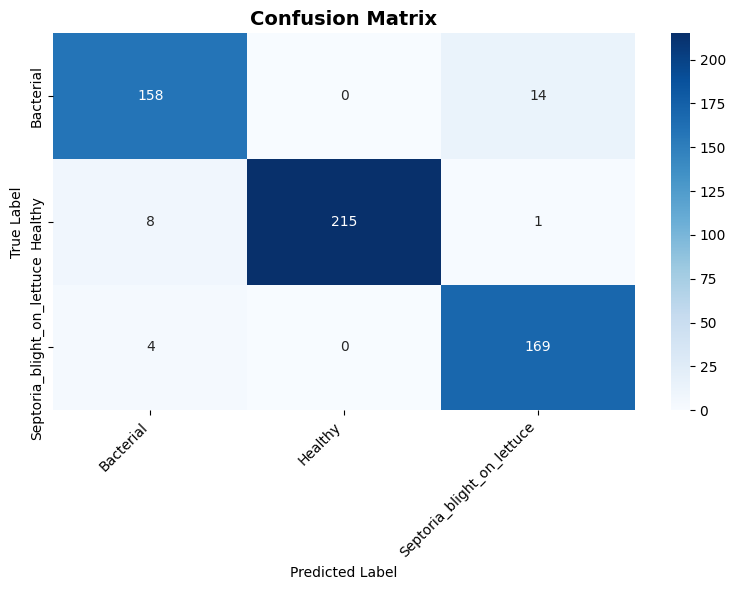

✅ Confusion matrix saved as confusion_matrix.png


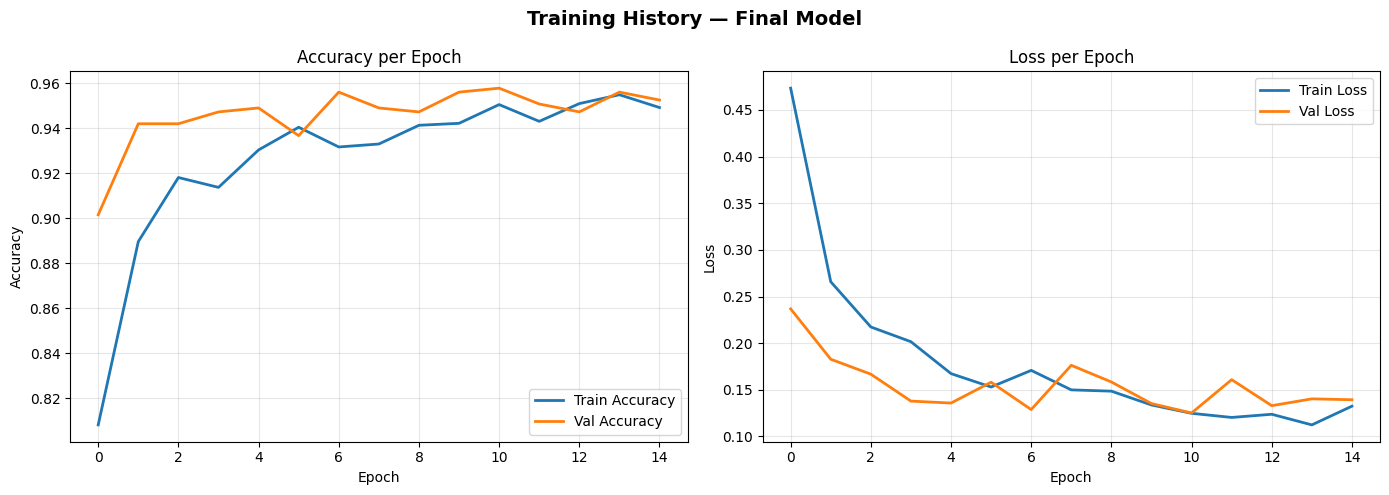

✅ Training curves saved as training_curves.png


In [ ]:
# ===============================
# FINAL ACCURACY EVALUATION
# For Thesis Reporting
# ===============================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

# ===============================
# Load Model & Get Predictions
# ===============================

model = tf.keras.models.load_model("lettuce_mobilenetv2.keras")

val_generator.reset()
pred = model.predict(val_generator)
pred_classes = np.argmax(pred, axis=1)
true_classes = val_generator.classes
labels = list(val_generator.class_indices.keys())

# ===============================
# PRINT ALL ACCURACY METRICS
# ===============================

overall_acc   = accuracy_score(true_classes, pred_classes)
macro_f1      = f1_score(true_classes, pred_classes, average='macro')
weighted_f1   = f1_score(true_classes, pred_classes, average='weighted')

print("=" * 55)
print("        FINAL MODEL ACCURACY — THESIS REPORT")
print("=" * 55)
print(f"  Overall Accuracy   : {overall_acc * 100:.2f}%")
print(f"  Macro F1-Score     : {macro_f1:.4f}  ← report this too")
print(f"  Weighted F1-Score  : {weighted_f1:.4f}")
print("=" * 55)

print("\n📊 Per-Class Report:")
print(classification_report(true_classes, pred_classes, target_names=labels))

print("\n📈 Per-Class Accuracy:")
for i, label in enumerate(labels):
    mask     = (true_classes == i)
    acc      = np.mean(pred_classes[mask] == true_classes[mask]) * 100
    total    = np.sum(mask)
    print(f"  {label:<30} {acc:5.1f}%  ({total} samples)")

# ===============================
# CONFUSION MATRIX
# ===============================

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Confusion Matrix", fontsize=14, fontweight='bold')
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Confusion matrix saved as confusion_matrix.png")

# ===============================
# ACCURACY & LOSS CURVES
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training History — Final Model", fontsize=14, fontweight='bold')

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2)
axes[0].set_title("Accuracy per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   linewidth=2)
axes[1].set_title("Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("✅ Training curves saved as training_curves.png")

In [ ]:
from google.colab import files

files.download("lettuce_mobilenetv2.h5")
files.download("lettuce_mobilenetv2.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saving bct (3).jpg to bct (3) (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


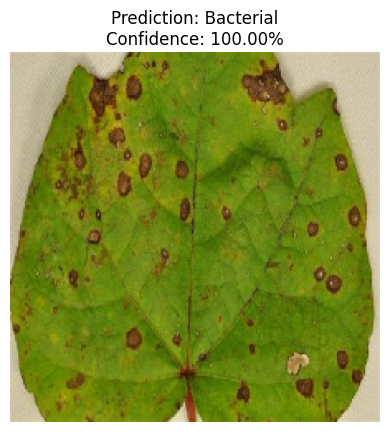

Prediction: Bacterial
Confidence: 99.99944


In [ ]:
# ===============================
# Upload Image + Test Prediction
# ===============================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from google.colab import files

# Load trained model
model = tf.keras.models.load_model("lettuce_mobilenetv2.keras")

# Upload image
uploaded = files.upload()

# Get uploaded image name
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))

# Convert to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

# Classes (must match training order)
classes = ['Bacterial', 'Healthy', 'Septoria_blight_on_lettuce']

predicted_class = classes[np.argmax(prediction)]
confidence = np.max(prediction) * 100

# Show image
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.show()

print("Prediction:", predicted_class)
print("Confidence:", confidence)